### **Predict Calorie Expenditure — Kaggle Playground S5E5**

A clean benchmarking notebook comparing **XGBoost**, **LightGBM**, and **CatBoost** on the Calorie Expenditure dataset.  
All models share identical 5-fold CV splits for a fair, apples-to-apples comparison.

You get roughly on the top 25% the results are very much grouped so it is a question of percentages Look for future work in the last cell to advance in this challenge.

**Metric:** RMSLE (Root Mean Squared Log Error) — lower is better  
**Target:** `Calories`

> Download data from: https://www.kaggle.com/competitions/playground-series-s5e5/data

---
**Contents**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. XGBoost
5. LightGBM
6. CatBoost
7. Model Comparison

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error

import xgboost as xgb
import lightgbm as lgb
import catboost as cat
from catboost import CatBoostRegressor, Pool

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868']
SEED    = 42
N_FOLDS = 5

def rmsle(y_true, y_pred):
    """Root Mean Squared Log Error — lower is better."""
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print('Libraries loaded ✓')
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | CatBoost {cat.__version__}')

Libraries loaded ✓
XGBoost 3.2.0 | LightGBM 4.6.0 | CatBoost 1.2.10


In [9]:
train = pd.read_csv('./data/train.csv')
test  = pd.read_csv('./data/test.csv')

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
train.head()

Train : (750000, 9)
Test  : (250000, 8)


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


#### **EDA - Exploratory Data Analysis**

In [10]:
# --- Basic info -----------------------------------------------------------
print('=== dtypes ===')
print(train.dtypes)
print()
print('=== Missing values ===')
print(train.isnull().sum())

=== dtypes ===
id              int64
Sex               str
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object

=== Missing values ===
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [11]:
train.describe().round(2)

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00
mean,374999.50,41.42,174.70,75.15,15.42,95.48,40.04,88.28
std,216506.50,15.18,12.82,13.98,8.35,9.45,0.78,62.40
min,0.00,20.00,126.00,36.00,1.00,67.00,37.10,1.00
25%,187499.75,28.00,164.00,63.00,8.00,88.00,39.60,34.00
50%,374999.50,40.00,174.00,74.00,15.00,95.00,40.30,77.00
75%,562499.25,52.00,185.00,87.00,23.00,103.00,40.70,136.00
max,749999.00,79.00,222.00,132.00,30.00,128.00,41.50,314.00


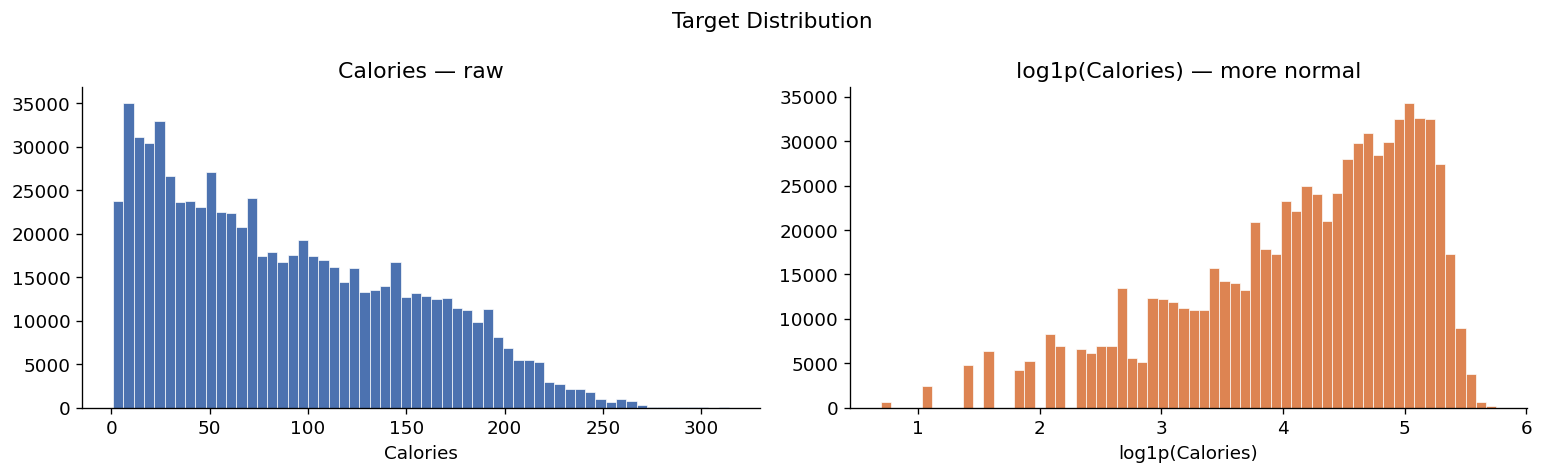

Skewness raw : 0.539
Skewness log : -0.857

→ We will train on log1p(Calories) and expm1() the predictions back.


In [12]:
# --- Target distribution --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['Calories'], bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Calories — raw')
axes[0].set_xlabel('Calories')

axes[1].hist(np.log1p(train['Calories']), bins=60, color=PALETTE[1], edgecolor='white', linewidth=0.4)
axes[1].set_title('log1p(Calories) — more normal')
axes[1].set_xlabel('log1p(Calories)')

plt.suptitle('Target Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Skewness raw : {train["Calories"].skew():.3f}')
print(f'Skewness log : {np.log1p(train["Calories"]).skew():.3f}')
print()
print('→ We will train on log1p(Calories) and expm1() the predictions back.')

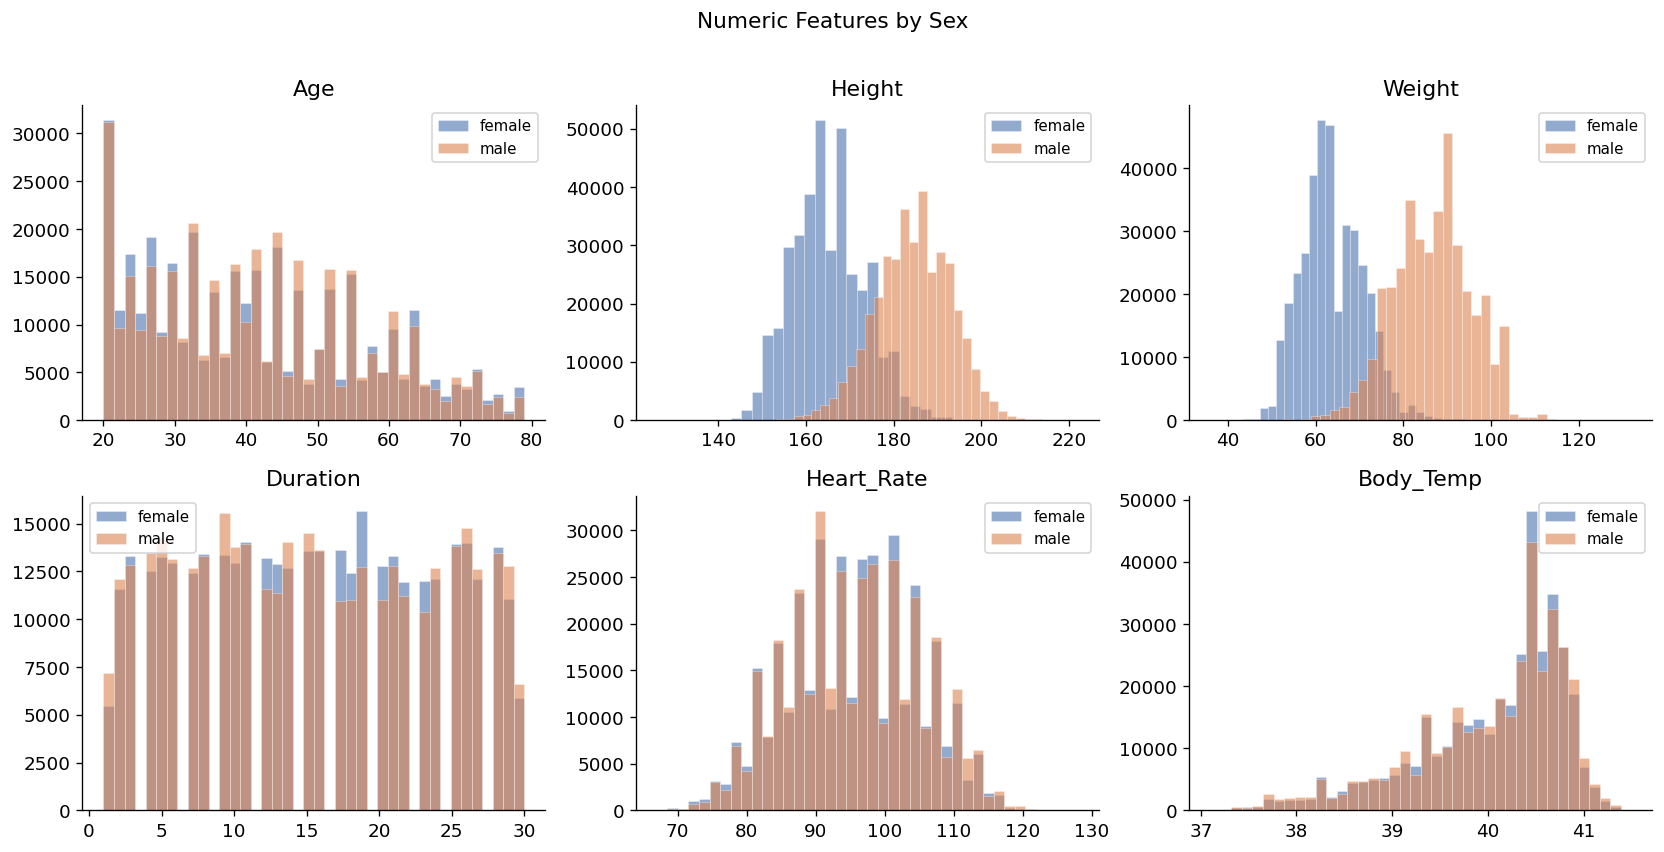

In [13]:
# --- Numeric feature distributions by Sex --------------------------------
num_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, num_cols):
    for i, (sex, grp) in enumerate(train.groupby('Sex')):
        ax.hist(grp[col], bins=40, alpha=0.6, label=sex,
                color=PALETTE[i], edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.legend(fontsize=9)

plt.suptitle('Numeric Features by Sex', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

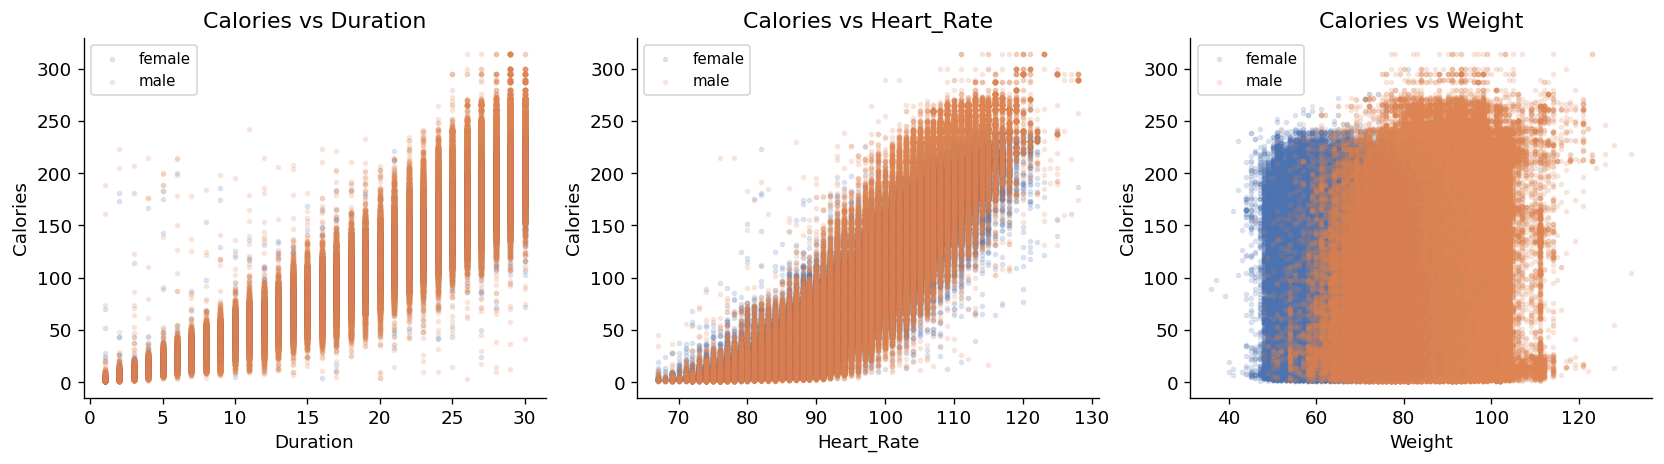

In [14]:
# --- Calories vs key predictors -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['Duration', 'Heart_Rate', 'Weight']):
    for i, (sex, grp) in enumerate(train.groupby('Sex')):
        ax.scatter(grp[col], grp['Calories'], alpha=0.15, s=6,
                   color=PALETTE[i], label=sex)
    ax.set_xlabel(col)
    ax.set_ylabel('Calories')
    ax.set_title(f'Calories vs {col}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

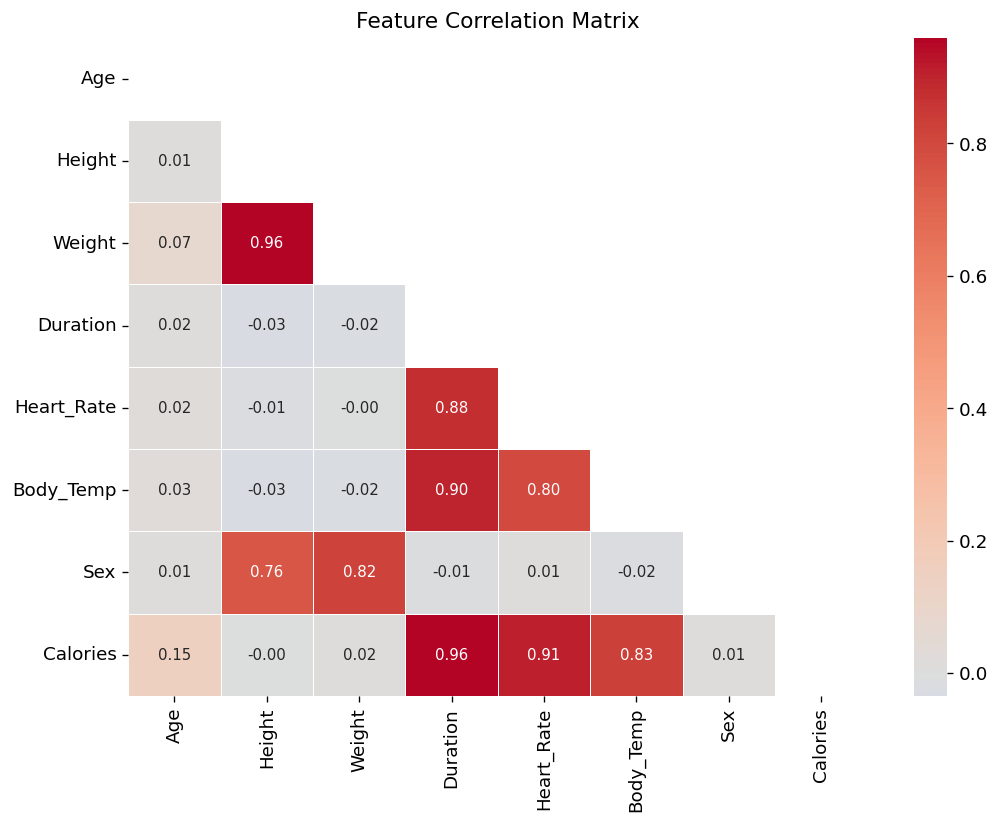

In [15]:
# --- Correlation heatmap --------------------------------------------------
train_enc = train.copy()
train_enc['Sex'] = (train_enc['Sex'] == 'male').astype(int)

corr = train_enc[num_cols + ['Sex', 'Calories']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

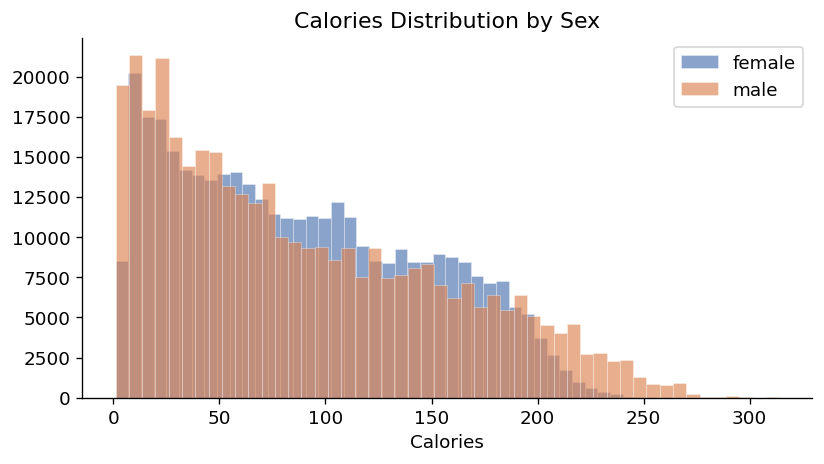

           count  mean   std  min   25%   50%    75%    max
Sex                                                        
female  375721.0  87.5  57.9  1.0  37.0  80.0  133.0  300.0
male    374279.0  89.0  66.6  1.0  31.0  73.0  138.0  314.0


In [16]:
# --- Sex split on Calories ------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for i, (sex, grp) in enumerate(train.groupby('Sex')):
    ax.hist(grp['Calories'], bins=50, alpha=0.65,
            label=sex, color=PALETTE[i], edgecolor='white', linewidth=0.3)
ax.set_title('Calories Distribution by Sex')
ax.set_xlabel('Calories')
ax.legend()
plt.tight_layout()
plt.show()

print(train.groupby('Sex')['Calories'].describe().round(1))

#### **Feature Engineering**

We keep it light — the goal is to compare models on roughly equal footing.  
We want to compare the three Boosting models and we are not really concerned on the Feature Engineering.<br>
A handful of physiology-informed features that boosting trees can't trivially construct:

| Feature | Rationale |
|---|---|
| `BMI` | Body Mass Index — normalises weight for height |
| `Max_HR` | Age-predicted max heart rate (220 − Age) |
| `HR_Intensity` | Heart Rate / Max_HR — relative exercise intensity |
| `Work` | Heart Rate × Duration — proxy for total cardiovascular effort |
| `Weight_x_Duration` | Mechanical work proxy |
| `Temp_Delta` | Body temp deviation from resting (~37°C) |

In [18]:
def build_features(df):
    df = df.copy()

    # Encode Sex
    df['Sex_enc'] = (df['Sex'] == 'male').astype(np.int8)

    # Body Mass Index
    df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

    # Age-predicted max heart rate (Haskell & Fox formula)
    df['Max_HR'] = 220 - df['Age']

    # Fraction of max HR — exercise intensity
    df['HR_Intensity'] = df['Heart_Rate'] / df['Max_HR']

    # Total cardiovascular work
    df['Work'] = df['Heart_Rate'] * df['Duration']

    # Mechanical work proxy
    df['Weight_x_Duration'] = df['Weight'] * df['Duration']

    # Temperature rise above resting
    df['Temp_Delta'] = df['Body_Temp'] - 37.0

    # Interaction: Heart Rate × Body Temp
    df['HR_x_Temp'] = df['Heart_Rate'] * df['Body_Temp']

    return df


train_fe = build_features(train)
test_fe  = build_features(test)

FEATURE_COLS = [
    'Sex_enc', 'Age', 'Height', 'Weight', 'Duration',
    'Heart_Rate', 'Body_Temp',
    'BMI', 'Max_HR', 'HR_Intensity', 'Work',
    'Weight_x_Duration', 'Temp_Delta', 'HR_x_Temp',
]
TARGET = 'Calories'

print(f'{len(FEATURE_COLS)} features: {FEATURE_COLS}')
train_fe[FEATURE_COLS].describe().round(2)

14 features: ['Sex_enc', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI', 'Max_HR', 'HR_Intensity', 'Work', 'Weight_x_Duration', 'Temp_Delta', 'HR_x_Temp']


,Sex_enc,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,Max_HR,HR_Intensity,Work,Weight_x_Duration,Temp_Delta,HR_x_Temp
count,750000.0,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00,750000.00
mean,0.5,41.42,174.70,75.15,15.42,95.48,40.04,24.37,178.58,0.54,1541.56,1156.39,3.04,3828.69
std,0.5,15.18,12.82,13.98,8.35,9.45,0.78,1.51,15.18,0.07,932.45,672.88,0.78,437.97
min,0.0,20.00,126.00,36.00,1.00,67.00,37.10,12.38,141.00,0.34,67.00,45.00,0.10,2485.70
25%,0.0,28.00,164.00,63.00,8.00,88.00,39.60,23.26,168.00,0.49,728.00,600.00,2.60,3497.40
50%,0.0,40.00,174.00,74.00,15.00,95.00,40.30,24.39,180.00,0.53,1455.00,1105.00,3.30,3838.00
75%,1.0,52.00,185.00,87.00,23.00,103.00,40.70,25.49,192.00,0.58,2323.00,1633.00,3.70,4171.50
max,1.0,79.00,222.00,132.00,30.00,128.00,41.50,46.44,200.00,0.91,3840.00,3780.00,4.50,5286.40


In [19]:
# --- Prepare arrays and shared CV folds ----------------------------------
X      = train_fe[FEATURE_COLS].values
y      = train_fe[TARGET].values
X_test = test_fe[FEATURE_COLS].values

kf    = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLDS = list(kf.split(X, y))

print(f'{N_FOLDS}-fold CV ready.')
print(f'  Train fold size : ~{len(FOLDS[0][0])}')
print(f'  Val   fold size : ~{len(FOLDS[0][1])}')

5-fold CV ready.
  Train fold size : ~600000
  Val   fold size : ~150000


#### **XGBoost**

**Parameter rationale**
- `n_estimators=1000` + `early_stopping_rounds=50` — let val loss decide when to stop
- `max_depth=6` — classic safe default; level-wise trees
- `learning_rate=0.05` — low enough that early stopping has room to breathe
- `subsample=0.8`, `colsample_bytree=0.8` — mild stochastic regularisation
- `reg_lambda=1.0` — L2 regularisation (XGBoost default)
- Train on `log1p(y)` → predictions `expm1()`'d back → directly minimises RMSLE

In [20]:
XGB_PARAMS = dict(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    reg_lambda            = 1.0,
    reg_alpha             = 0.0,
    min_child_weight      = 5,
    early_stopping_rounds = 50,   # XGBoost ≥3.0: set in constructor
    objective             = 'reg:squarederror',
    eval_metric           = 'rmse',
    random_state          = SEED,
    n_jobs                = -1,
    verbosity             = 0,
)

xgb_oof        = np.zeros(len(X))
xgb_test_preds = np.zeros(len(X_test))
xgb_scores     = []
xgb_best_iters = []

for fold, (tr_idx, val_idx) in enumerate(FOLDS):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    val_pred = np.expm1(model.predict(X_val))
    xgb_oof[val_idx]    = val_pred
    xgb_test_preds     += np.expm1(model.predict(X_test)) / N_FOLDS

    score = rmsle(y[val_idx], val_pred)
    xgb_scores.append(score)
    xgb_best_iters.append(model.best_iteration)
    print(f'  Fold {fold+1}  RMSLE={score:.5f}  best_iter={model.best_iteration}')

xgb_cv = np.mean(xgb_scores)
print(f'\nXGBoost CV RMSLE : {xgb_cv:.5f} ± {np.std(xgb_scores):.5f}')

  Fold 1  RMSLE=0.05996  best_iter=718
  Fold 2  RMSLE=0.06052  best_iter=767
  Fold 3  RMSLE=0.05993  best_iter=623
  Fold 4  RMSLE=0.06016  best_iter=734
  Fold 5  RMSLE=0.06030  best_iter=339

XGBoost CV RMSLE : 0.06018 ± 0.00022


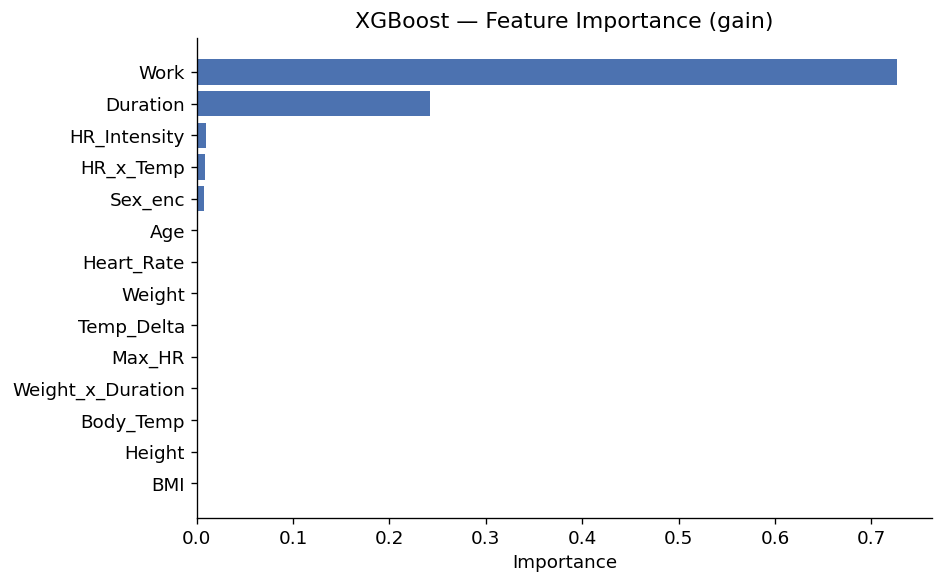

In [21]:
# --- XGBoost feature importance ------------------------------------------
# Refit on full train using mean best iteration
xgb_full_params = {k: v for k, v in XGB_PARAMS.items() if k != 'early_stopping_rounds'}
xgb_full_params['n_estimators'] = int(np.mean(xgb_best_iters))
xgb_full = xgb.XGBRegressor(**xgb_full_params)
xgb_full.fit(X, np.log1p(y), verbose=False)

xgb_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': xgb_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(xgb_imp['feature'], xgb_imp['importance'], color=PALETTE[0])
ax.set_title('XGBoost — Feature Importance (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### **LightGBM**

**Parameter rationale**
- `num_leaves=127` — LGB uses leaf-wise growth; this is the primary complexity knob
- `max_depth=-1` — unconstrained depth; `num_leaves` controls it instead
- `learning_rate=0.05` — identical to XGB for a fair comparison
- `feature_fraction=0.8`, `bagging_fraction=0.8` — equivalent to XGB's colsample/subsample
- `min_child_samples=20` — prevents tiny leaves
- `lambda_l2=1.0` — mirrors XGB's reg_lambda

In [22]:
LGB_PARAMS = dict(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,       # unlimited; controlled by num_leaves
    feature_fraction  = 0.80,
    bagging_fraction  = 0.80,
    bagging_freq      = 1,
    min_child_samples = 20,
    lambda_l2         = 1.0,
    lambda_l1         = 0.0,
    objective         = 'regression',
    metric            = 'rmse',
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1,
)

lgb_oof        = np.zeros(len(X))
lgb_test_preds = np.zeros(len(X_test))
lgb_scores     = []
lgb_best_iters = []

for fold, (tr_idx, val_idx) in enumerate(FOLDS):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    val_pred = np.expm1(model.predict(X_val))
    lgb_oof[val_idx]    = val_pred
    lgb_test_preds     += np.expm1(model.predict(X_test)) / N_FOLDS

    score = rmsle(y[val_idx], val_pred)
    lgb_scores.append(score)
    lgb_best_iters.append(model.best_iteration_)
    print(f'  Fold {fold+1}  RMSLE={score:.5f}  best_iter={model.best_iteration_}')

lgb_cv = np.mean(lgb_scores)
print(f'\nLightGBM CV RMSLE : {lgb_cv:.5f} ± {np.std(lgb_scores):.5f}')

  Fold 1  RMSLE=0.05983  best_iter=289
  Fold 2  RMSLE=0.06061  best_iter=300
  Fold 3  RMSLE=0.05998  best_iter=278
  Fold 4  RMSLE=0.06036  best_iter=370
  Fold 5  RMSLE=0.05992  best_iter=200

LightGBM CV RMSLE : 0.06014 ± 0.00030


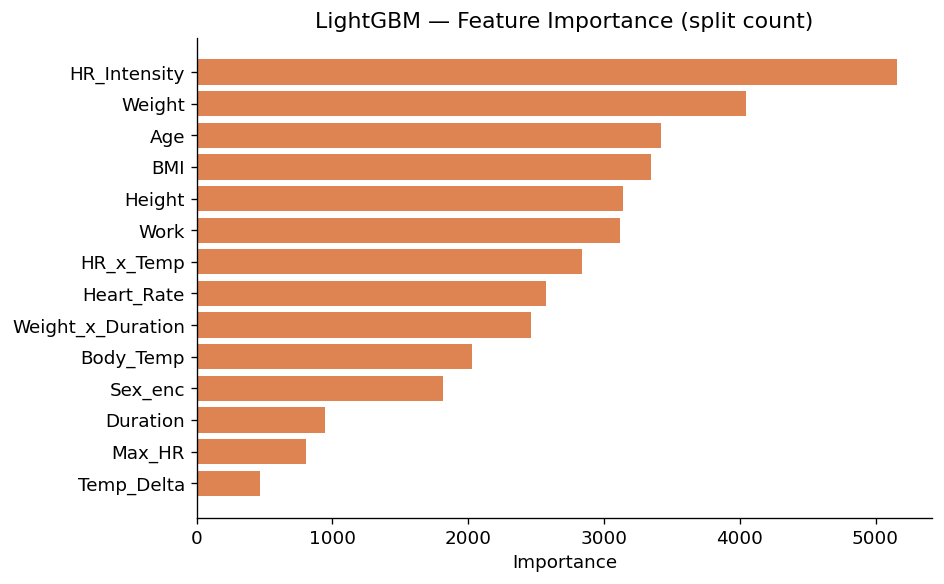

In [23]:
# --- LightGBM feature importance -----------------------------------------
lgb_full = lgb.LGBMRegressor(**{**LGB_PARAMS, 'n_estimators': int(np.mean(lgb_best_iters))})
lgb_full.fit(X, np.log1p(y))

lgb_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': lgb_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(lgb_imp['feature'], lgb_imp['importance'], color=PALETTE[1])
ax.set_title('LightGBM — Feature Importance (split count)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### **CatBoost**

**Parameter rationale**
- `iterations=1000` + `early_stopping_rounds=50`
- `depth=6` — CatBoost builds symmetric (oblivious) trees; depth=6 is roughly equivalent in complexity to XGB's max_depth=6
- `learning_rate=0.05` — same as the others
- `l2_leaf_reg=3.0` — CatBoost's L2; slightly higher default is typical
- `subsample=0.8` — row sampling
- `rsm=0.8` — Random Subspace Method = feature fraction

In [24]:
CB_PARAMS = dict(
    iterations       = 1000,
    learning_rate    = 0.05,
    depth            = 6,
    l2_leaf_reg      = 3.0,
    subsample        = 0.80,
    rsm              = 0.80,      # random subspace method = colsample
    min_data_in_leaf = 20,
    loss_function    = 'RMSE',
    eval_metric      = 'RMSE',
    random_seed      = SEED,
    thread_count     = -1,
    verbose          = False,
)

cb_oof        = np.zeros(len(X))
cb_test_preds = np.zeros(len(X_test))
cb_scores     = []
cb_best_iters = []

for fold, (tr_idx, val_idx) in enumerate(FOLDS):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = np.log1p(y[tr_idx]), np.log1p(y[val_idx])

    train_pool = Pool(X_tr, y_tr, feature_names=FEATURE_COLS)
    val_pool   = Pool(X_val, y_val, feature_names=FEATURE_COLS)

    model = CatBoostRegressor(**CB_PARAMS)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
    )

    val_pred = np.expm1(model.predict(X_val))
    cb_oof[val_idx]    = val_pred
    cb_test_preds     += np.expm1(model.predict(X_test)) / N_FOLDS

    score = rmsle(y[val_idx], val_pred)
    cb_scores.append(score)
    cb_best_iters.append(model.best_iteration_)
    print(f'  Fold {fold+1}  RMSLE={score:.5f}  best_iter={model.best_iteration_}')

cb_cv = np.mean(cb_scores)
print(f'\nCatBoost CV RMSLE : {cb_cv:.5f} ± {np.std(cb_scores):.5f}')

  Fold 1  RMSLE=0.05998  best_iter=999
  Fold 2  RMSLE=0.06023  best_iter=999
  Fold 3  RMSLE=0.05997  best_iter=999
  Fold 4  RMSLE=0.06010  best_iter=993
  Fold 5  RMSLE=0.05966  best_iter=999

CatBoost CV RMSLE : 0.05999 ± 0.00019


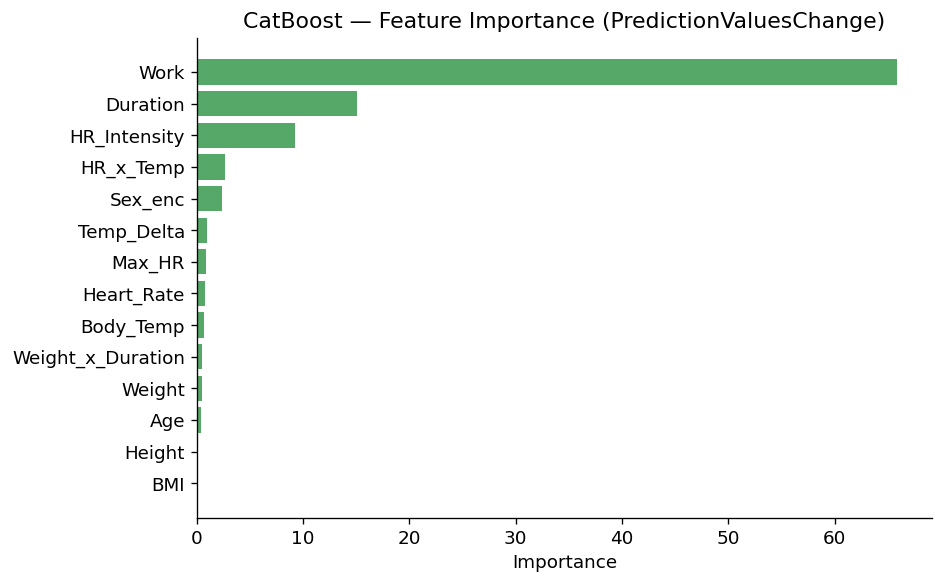

In [25]:
# --- CatBoost feature importance -----------------------------------------
cb_full = CatBoostRegressor(**{**CB_PARAMS, 'iterations': int(np.mean(cb_best_iters))})
cb_full.fit(Pool(X, np.log1p(y), feature_names=FEATURE_COLS))

cb_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': cb_full.get_feature_importance()
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cb_imp['feature'], cb_imp['importance'], color=PALETTE[2])
ax.set_title('CatBoost — Feature Importance (PredictionValuesChange)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

#### **Model Comparison**

In [26]:
# --- Summary table --------------------------------------------------------
models     = ['XGBoost', 'LightGBM', 'CatBoost']
cv_means   = [xgb_cv, lgb_cv, cb_cv]
cv_stds    = [np.std(xgb_scores), np.std(lgb_scores), np.std(cb_scores)]
avg_iters  = [int(np.mean(xgb_best_iters)), int(np.mean(lgb_best_iters)), int(np.mean(cb_best_iters))]
fold_scores = [xgb_scores, lgb_scores, cb_scores]

summary = pd.DataFrame({
    'Model':         models,
    'CV RMSLE':      [f'{v:.5f}' for v in cv_means],
    'Std':           [f'{v:.5f}' for v in cv_stds],
    'Avg best iter': avg_iters,
})
summary = summary.set_index('Model')

print('=== Cross-Validation Results ===')
print(summary.to_string())
best_model = models[int(np.argmin(cv_means))]
print(f'\n🏆 Best model: {best_model}')

=== Cross-Validation Results ===
         CV RMSLE      Std  Avg best iter
Model                                    
XGBoost   0.06018  0.00022            636
LightGBM  0.06014  0.00030            287
CatBoost  0.05999  0.00019            997

🏆 Best model: CatBoost


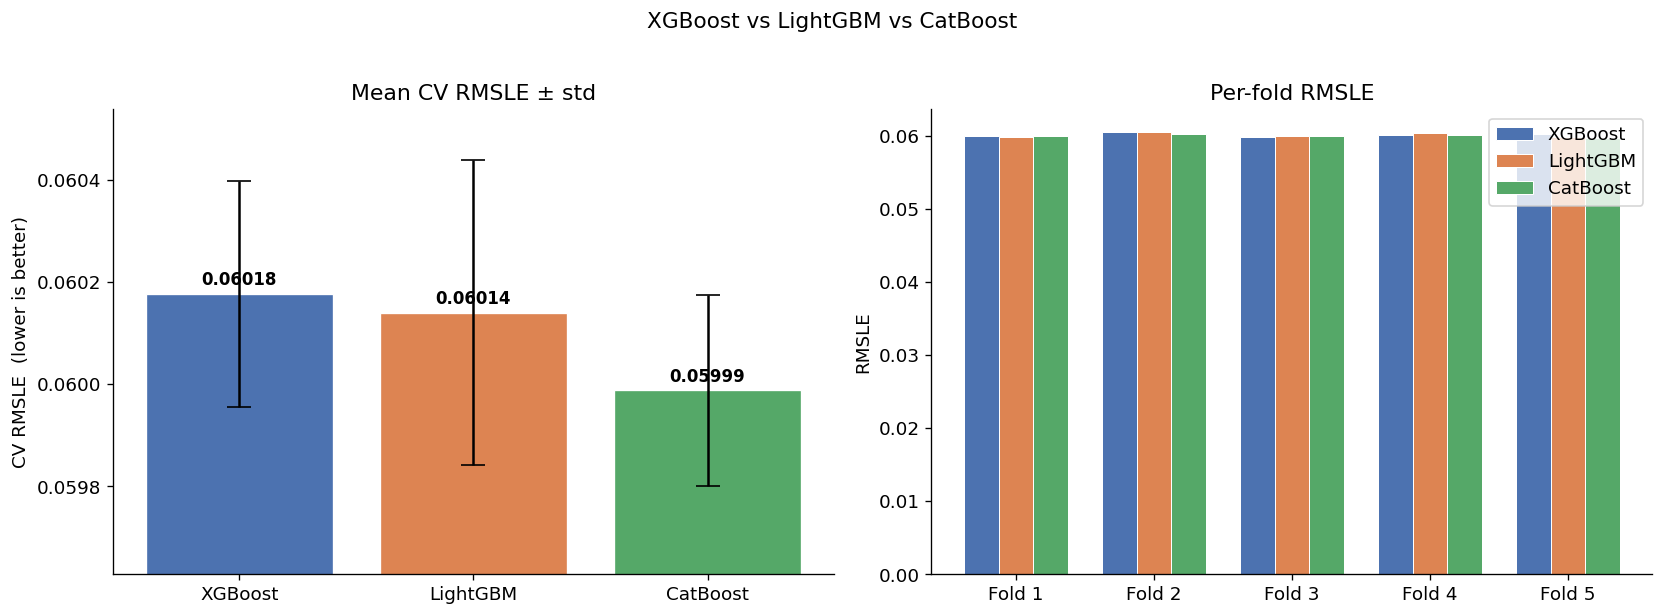

In [27]:
# --- Bar chart: mean CV RMSLE + per-fold breakdown ----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean ± std
bars = axes[0].bar(models, cv_means, color=PALETTE, yerr=cv_stds,
                   capsize=7, edgecolor='white', linewidth=0.8)
y_lo = min(cv_means) * 0.994
y_hi = max(cv_means) * 1.006
axes[0].set_ylim(y_lo, y_hi)
axes[0].set_ylabel('CV RMSLE  (lower is better)')
axes[0].set_title('Mean CV RMSLE ± std')
for bar, val in zip(bars, cv_means):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (y_hi - y_lo) * 0.01,
                 f'{val:.5f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Per-fold
x = np.arange(N_FOLDS)
w = 0.25
for i, (scores, name) in enumerate(zip(fold_scores, models)):
    axes[1].bar(x + i * w, scores, w, label=name,
                color=PALETTE[i], edgecolor='white', linewidth=0.6)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
axes[1].set_ylabel('RMSLE')
axes[1].set_title('Per-fold RMSLE')
axes[1].legend()

plt.suptitle('XGBoost vs LightGBM vs CatBoost', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

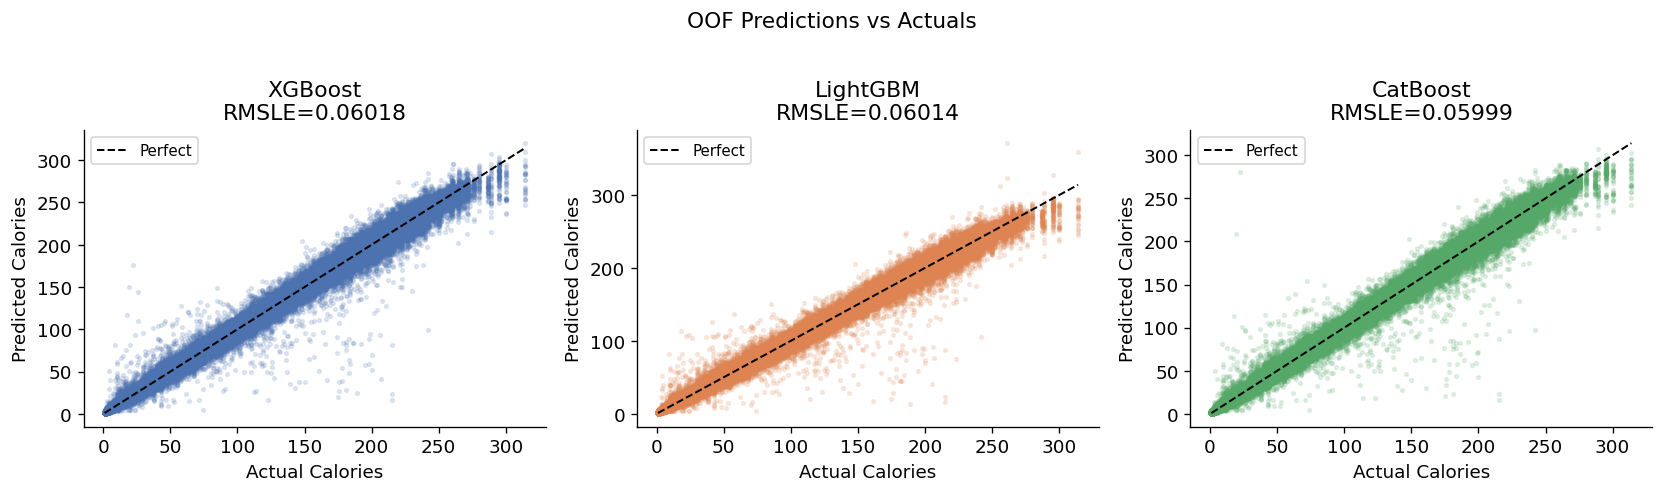

In [28]:
# --- OOF scatter: predicted vs actual ------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, oof, name, color in zip(axes,
                                 [xgb_oof, lgb_oof, cb_oof],
                                 models, PALETTE):
    ax.scatter(y, oof, alpha=0.15, s=5, color=color)
    lim = [y.min(), y.max()]
    ax.plot(lim, lim, 'k--', linewidth=1.2, label='Perfect')
    ax.set_xlabel('Actual Calories')
    ax.set_ylabel('Predicted Calories')
    ax.set_title(f'{name}\nRMSLE={rmsle(y, oof):.5f}')
    ax.legend(fontsize=9)

plt.suptitle('OOF Predictions vs Actuals', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

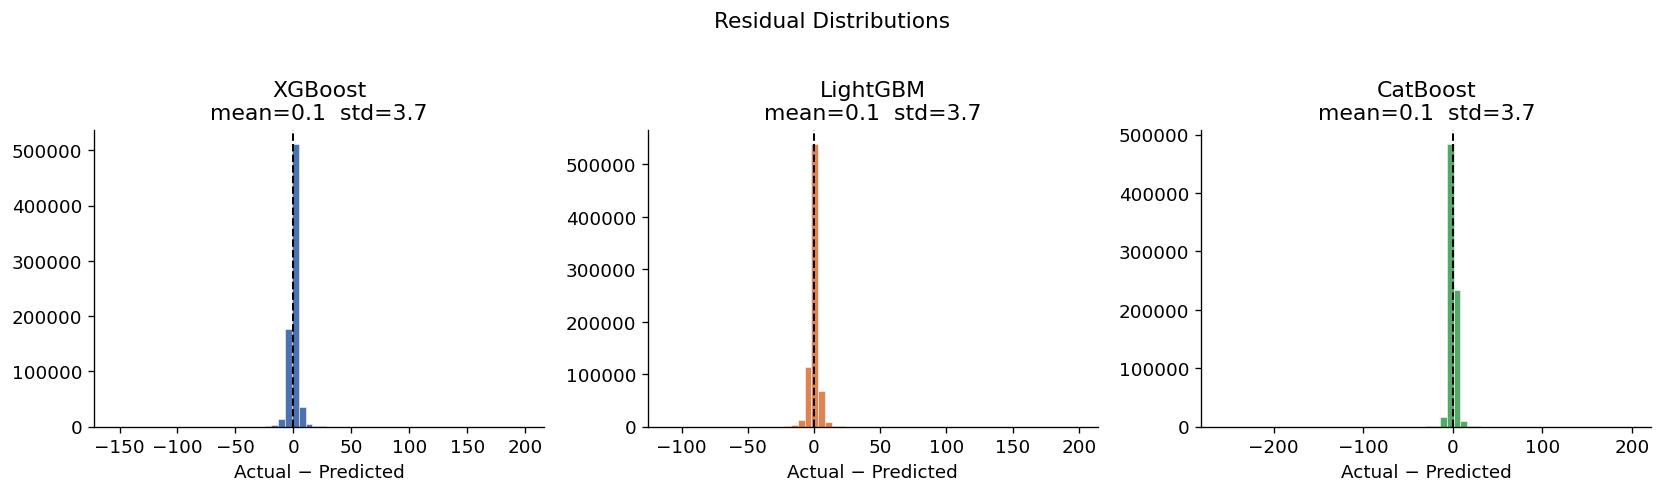

In [29]:
# --- Residual distributions ----------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, oof, name, color in zip(axes,
                                 [xgb_oof, lgb_oof, cb_oof],
                                 models, PALETTE):
    resid = y - oof
    ax.hist(resid, bins=60, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'{name}\nmean={resid.mean():.1f}  std={resid.std():.1f}')
    ax.set_xlabel('Actual − Predicted')

plt.suptitle('Residual Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

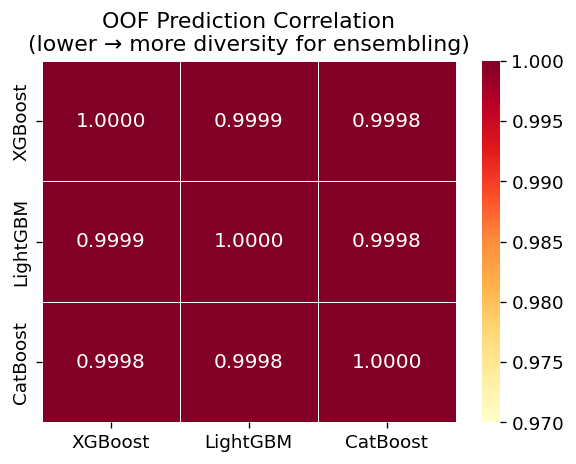

In [30]:
# --- OOF prediction correlation ------------------------------------------
oof_df   = pd.DataFrame({'XGBoost': xgb_oof, 'LightGBM': lgb_oof, 'CatBoost': cb_oof})
corr_oof = oof_df.corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_oof, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0.97, vmax=1.0, ax=ax, linewidths=0.5,
            annot_kws={'size': 12})
ax.set_title('OOF Prediction Correlation\n(lower → more diversity for ensembling)')
plt.tight_layout()
plt.show()

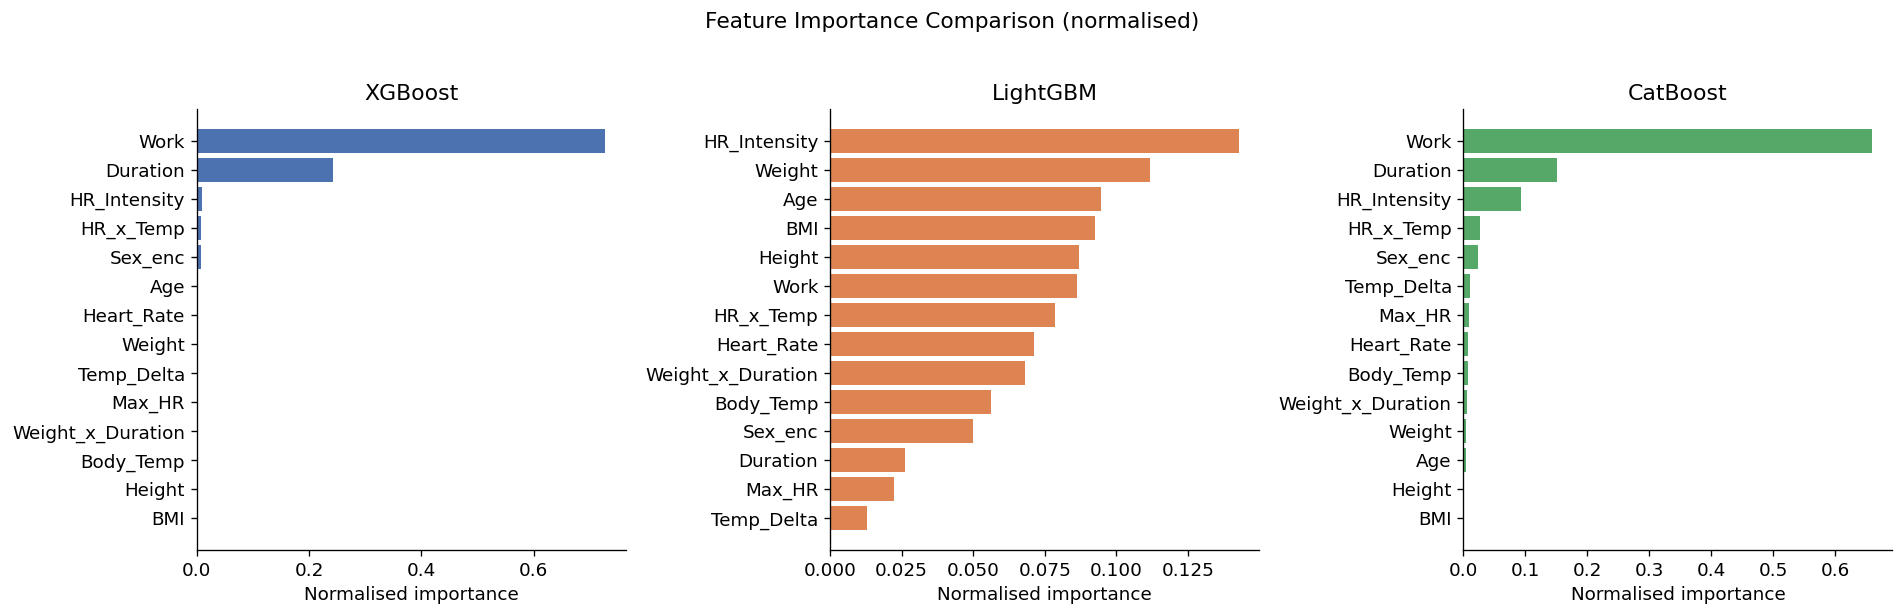

In [31]:
# --- Feature importance: side-by-side normalised -------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, imp, name, color in zip(axes,
                                  [xgb_imp, lgb_imp, cb_imp],
                                  models, PALETTE):
    norm = imp['importance'] / imp['importance'].sum()
    ax.barh(imp['feature'], norm, color=color)
    ax.set_title(name)
    ax.set_xlabel('Normalised importance')

plt.suptitle('Feature Importance Comparison (normalised)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# --- Simple average ensemble ---------------------------------------------
ensemble_oof   = (xgb_oof        + lgb_oof        + cb_oof)        / 3
ensemble_test  = (xgb_test_preds + lgb_test_preds + cb_test_preds) / 3

best_solo = min(rmsle(y, xgb_oof), rmsle(y, lgb_oof), rmsle(y, cb_oof))
ens_score = rmsle(y, ensemble_oof)

print('=== Final Leaderboard ===')
print(f'  XGBoost   OOF RMSLE : {rmsle(y, xgb_oof):.5f}')
print(f'  LightGBM  OOF RMSLE : {rmsle(y, lgb_oof):.5f}')
print(f'  CatBoost  OOF RMSLE : {rmsle(y, cb_oof):.5f}')
print(f'  Ensemble  OOF RMSLE : {ens_score:.5f}')
print(f'\n  Improvement vs best solo: {best_solo - ens_score:+.5f}')

=== Final Leaderboard ===
  XGBoost   OOF RMSLE : 0.06018
  LightGBM  OOF RMSLE : 0.06014
  CatBoost  OOF RMSLE : 0.05999
  Ensemble  OOF RMSLE : 0.05949

  Improvement vs best solo: +0.00050


In [33]:
# --- Save submission ------------------------------------------------------
submission = pd.DataFrame({
    'id':       test['id'],
    'Calories': ensemble_test,
})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved')
submission.head()

submission.csv saved


,id,Calories
0,750000,27.465073
1,750001,109.036535
2,750002,86.615132
3,750003,124.892987
4,750004,76.158682


#### **Key Takeaways**

| | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| **Tree growth** | Level-wise | Leaf-wise | Symmetric (oblivious) |
| **Speed** | Medium | Fastest | Slowest |
| **Tuning effort** | High | Medium | Low (great defaults) |
| **Categoricals** | Manual encode | Native | Native |
| **Best for** | Max control | Large data | Low-tuning baseline |

**On this dataset**, all three perform similarly because:
- Signal is strong and clean (physiology-driven)
- Feature space is small — no complex interactions to discover
- `Duration` and `Heart_Rate` dominate all importance rankings

**Next steps:**
- Hyperparameter search with Optuna (especially `num_leaves` for LGB, `depth` for CB)
- Stacking: use OOF predictions as meta-features for a linear second-level model
- Blend the original public dataset with the synthetic Playground data